In [1]:
import numpy as np
import os
from scipy.signal import stft
from skimage.transform import resize
import matplotlib.pyplot as plt

# === Load Dataset ===
data_dir = "dataset_200"
signals = np.load(os.path.join(data_dir, "200_train_signals.npy"))     # shape: (N, samples)
labels = np.load(os.path.join(data_dir, "200_train_labels.npy"))       # shape: (N,)

# === Output Directory (renamed) ===
output_dir = "200-MULTIspectrograms_custom_dataset_3ch"
os.makedirs(output_dir, exist_ok=True)

# === Parameters for STFT ===
fs = 10000                # Sampling rate used during signal generation
nperseg = 64
noverlap = 32
resize_shape = (32, 32)

# === Generate 3-Channel Spectrograms ===
spectrogram_list = []
for signal in signals:
    # Compute STFT
    f, t, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)

    # Channel 1: Magnitude
    mag = np.abs(Zxx)
    mag = mag / np.max(mag) if np.max(mag) > 0 else mag

    # Channel 2: sin(Phase), Channel 3: cos(Phase)
    phase = np.angle(Zxx)
    sin_phase = (np.sin(phase) + 1) / 2
    cos_phase = (np.cos(phase) + 1) / 2

    # Resize each to (32, 32)
    mag = resize(mag, resize_shape)
    sin_phase = resize(sin_phase, resize_shape)
    cos_phase = resize(cos_phase, resize_shape)

    # Stack into 3-channel image: (H, W, 3)
    spec_img = np.stack([mag, sin_phase, cos_phase], axis=-1)
    spectrogram_list.append(spec_img)

# === Convert to NumPy Array and Save ===
spectrogram_array = np.array(spectrogram_list, dtype=np.float16)
np.save(os.path.join(output_dir, "200_spectrograms_3ch.npy"), spectrogram_array)
np.save(os.path.join(output_dir, "200_labels.npy"), labels)

print(f"Saved 3-channel spectrograms to '{output_dir}' with shape: {spectrogram_array.shape}")


Saved 3-channel spectrograms to '200-MULTIspectrograms_custom_dataset_3ch' with shape: (24000, 32, 32, 3)


Epoch 1/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.4499 - loss: 1.3817 - val_accuracy: 0.5779 - val_loss: 1.3150 - learning_rate: 5.0000e-04
Epoch 2/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.8044 - loss: 0.5023 - val_accuracy: 0.9100 - val_loss: 0.2489 - learning_rate: 5.0000e-04
Epoch 3/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9067 - loss: 0.2638 - val_accuracy: 0.9242 - val_loss: 0.2130 - learning_rate: 5.0000e-04
Epoch 4/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9310 - loss: 0.1975 - val_accuracy: 0.9446 - val_loss: 0.1655 - learning_rate: 5.0000e-04
Epoch 5/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - accuracy: 0.9491 - loss: 0.1512 - val_accuracy: 0.9454 - val_loss: 0.1596 - learning_rate: 5.0000e-04
Epoch 6/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9549 - loss: 0.1268 - val_accuracy: 0.9517 - val_loss: 0.1406 - learning_rate: 5.0000e-04
Epoch 7/60
675/675 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/ste

Model trained with 90/10 split and saved successfully!


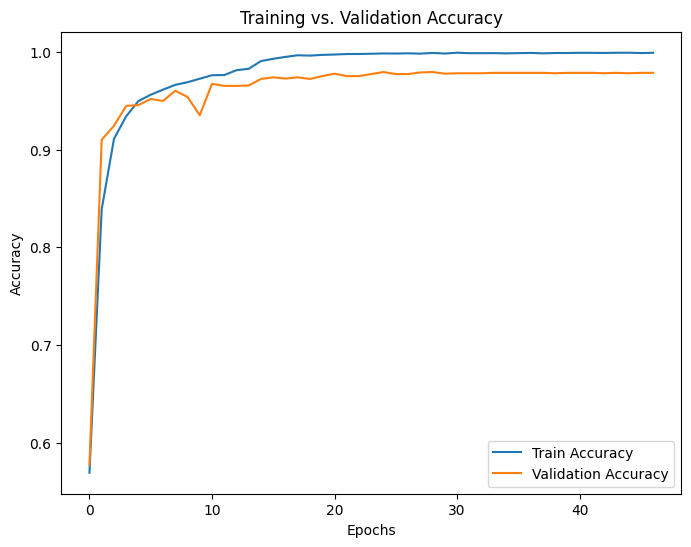

In [5]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import pickle

# === Load 3-channel Spectrogram Dataset ===
dataset_dir = "200-MULTIspectrograms_custom_dataset_3ch"
spectrograms_3ch = np.load(os.path.join(dataset_dir, "200_spectrograms_3ch.npy"))  # shape: (N, 32, 32, 3)
labels = np.load(os.path.join(dataset_dir, "200_labels.npy"))

# === Use ONLY the magnitude channel ===
spectrograms = spectrograms_3ch[..., 0]  # shape: (N, 32, 32)

# === Normalize and Reshape ===
spectrograms = spectrograms / np.max(spectrograms)
spectrograms = spectrograms[..., np.newaxis]  # shape: (N, 32, 32, 1)

# === Encode Labels ===
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_categorical = to_categorical(labels_encoded)

# === Split into Training and Validation (90/10) ===
X_train, X_val, y_train, y_val = train_test_split(
    spectrograms, labels_categorical, test_size=0.1, stratify=labels_categorical, random_state=42
)

# === Compute Class Weights ===
class_weights = compute_class_weight('balanced', classes=np.unique(labels_encoded), y=labels_encoded)
class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}

# === Learning Rate Scheduler ===
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1, min_lr=1e-7)
early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

# === CNN Model ===
model = Sequential([
    Input(shape=(32, 32, 1)),

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), padding='same'),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(len(np.unique(labels_encoded)), activation='softmax')
])

# === Compile Model ===
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['accuracy'])

# === Train Model ===
history = model.fit(
    X_train, y_train, batch_size=32,
    epochs=60, validation_data=(X_val, y_val),
    class_weight=class_weights_dict,
    callbacks=[lr_scheduler, early_stopping]
)

# === Save Trained Model and Label Encoder ===
model.save("200_cnn_modulation_classifier_custom_trained.h5")
with open("200_label_encoder_custom.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Model trained with 90/10 split and saved successfully!")

# === Optional: Plot Training History ===
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training vs. Validation Accuracy")
plt.show()


In [4]:
import numpy as np
import os
from scipy.signal import stft
from skimage.transform import resize
import matplotlib.pyplot as plt

# === Load Dataset ===
data_dir = "dataset_200"
signals = np.load(os.path.join(data_dir, "200_test_signals_snr16.npy"))     # shape: (N, samples)
labels = np.load(os.path.join(data_dir, "200_test_labels_snr16.npy"))       # shape: (N,)

# === Output Directory (renamed) ===
output_dir = "200-testMULTIspectrograms_custom_dataset_3ch"
os.makedirs(output_dir, exist_ok=True)

# === Parameters for STFT ===
fs = 10000                # Sampling rate used during signal generation
nperseg = 64
noverlap = 32
resize_shape = (32, 32)

# === Generate 3-Channel Spectrograms ===
spectrogram_list = []
for signal in signals:
    # Compute STFT
    f, t, Zxx = stft(signal, fs=fs, nperseg=nperseg, noverlap=noverlap)

    # Channel 1: Magnitude
    mag = np.abs(Zxx)
    mag = mag / np.max(mag) if np.max(mag) > 0 else mag

    # Channel 2: sin(Phase), Channel 3: cos(Phase)
    phase = np.angle(Zxx)
    sin_phase = (np.sin(phase) + 1) / 2
    cos_phase = (np.cos(phase) + 1) / 2

    # Resize each to (32, 32)
    mag = resize(mag, resize_shape)
    sin_phase = resize(sin_phase, resize_shape)
    cos_phase = resize(cos_phase, resize_shape)

    # Stack into 3-channel image: (H, W, 3)
    spec_img = np.stack([mag, sin_phase, cos_phase], axis=-1)
    spectrogram_list.append(spec_img)

# === Convert to NumPy Array and Save ===
spectrogram_array = np.array(spectrogram_list, dtype=np.float16)
np.save(os.path.join(output_dir, "200_spectrograms_16_3ch.npy"), spectrogram_array)
np.save(os.path.join(output_dir, "200_labels_16.npy"), labels)

print(f"Saved 3-channel spectrograms to '{output_dir}' with shape: {spectrogram_array.shape}")


Saved 3-channel spectrograms to '200-testMULTIspectrograms_custom_dataset_3ch' with shape: (1200, 32, 32, 3)


38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Sample Predictions:
Sample 0: Predicted = GFSK, Confidence = 100.00%
Sample 1: Predicted = GFSK, Confidence = 100.00%
Sample 2: Predicted = GFSK, Confidence = 100.00%
Sample 3: Predicted = GFSK, Confidence = 100.00%
Sample 4: Predicted = GFSK, Confidence = 100.00%


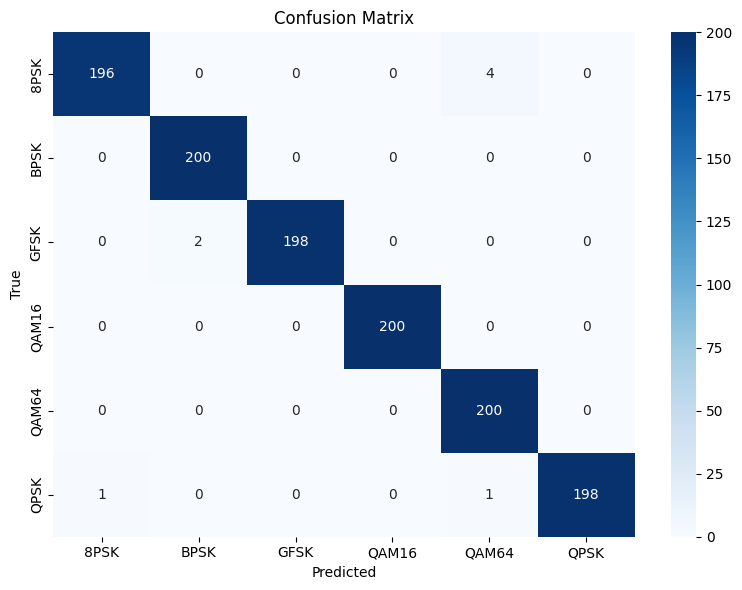


Classification Report:
               precision    recall  f1-score   support

        8PSK       0.99      0.98      0.99       200
        BPSK       0.99      1.00      1.00       200
        GFSK       1.00      0.99      0.99       200
       QAM16       1.00      1.00      1.00       200
       QAM64       0.98      1.00      0.99       200
        QPSK       1.00      0.99      0.99       200

    accuracy                           0.99      1200
   macro avg       0.99      0.99      0.99      1200
weighted avg       0.99      0.99      0.99      1200



In [10]:
import numpy as np
import os
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# === Load Trained Model & Label Encoder ===
model = load_model("200_cnn_modulation_classifier_custom_trained.h5")
with open("200_label_encoder_custom.pkl", "rb") as f:
    label_encoder = pickle.load(f)

# === Load Test Spectrograms ===
test_dir = "200-testMULTIspectrograms_custom_dataset_3ch"  # Change if using a different folder
X_test_3ch = np.load(os.path.join(test_dir, "200_spectrograms_12_3ch.npy"))  # shape: (N, 32, 32, 3)

# === Extract ONLY Magnitude Channel ===
X_test = X_test_3ch[..., 0]  # Use channel 0
X_test = X_test / np.max(X_test)
X_test = X_test[..., np.newaxis]  # shape: (N, 32, 32, 1)

# === Check if Labels Exist ===
has_labels = os.path.exists(os.path.join(test_dir, "200_labels_12.npy"))

if has_labels:
    y_test_raw = np.load(os.path.join(test_dir, "200_labels_12.npy"))
    y_test_encoded = label_encoder.transform(y_test_raw)
    y_test_categorical = to_categorical(y_test_encoded)

# === Predict ===
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
predicted_labels = label_encoder.inverse_transform(predicted_classes)

# === Show Top 5 Predictions ===
print("\nSample Predictions:")
for i in range(5):
    print(f"Sample {i}: Predicted = {predicted_labels[i]}, Confidence = {100 * np.max(predictions[i]):.2f}%")

# === Evaluate If Ground Truth Exists ===
if has_labels:
    true_classes = np.argmax(y_test_categorical, axis=1)

    # === Confusion Matrix ===
    conf_matrix = confusion_matrix(true_classes, predicted_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    # === Classification Report ===
    report = classification_report(true_classes, predicted_classes, target_names=label_encoder.classes_, zero_division=1)
    print("\nClassification Report:\n", report)
